# scikit-learn Bootcamp — W1, Day 5
```
##### Decision Trees
##### DecisionTreeClassifier · Gini impurity · max_depth · overfitting · feature importance
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: feature vs target boxplots, visual class separation
##### Q2 — Fit and plot a decision tree, interpret splits
##### Q3 — max_depth sweep: overfitting visualised
##### Q4 — Feature importance: Gini vs permutation
##### Q5 — Decision tree vs logistic regression: when does each win?
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

---
### Dataset — MedPulse Sessions (Synthetic)
```
# Same dataset as Days 1-4 for continuity.
```

In [2]:
np.random.seed(420)
n = 4000
age            = np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth  = np.random.poisson(3.8,n).clip(1,20)
time_on_site   = np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read  = np.random.poisson(2.5,n).clip(0,15)
is_mobile      = np.random.binomial(1,0.59,n)
health_content = np.random.beta(2.5,2,n)
log_odds       = (-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read
                  +1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted      = np.random.binomial(1,1/(1+np.exp(-log_odds)))
df = pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),
    'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols]; y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape: {df.shape} | Conversion: {y.mean():.2%}')

Shape: (4000, 7) | Conversion: 24.10%


In [3]:
display(df.head())

,age,session_depth,time_on_site,articles_read,is_mobile,health_content,converted
0,37,3,13.35,4,0,0.2969,0
1,20,3,2.03,4,0,0.5035,1
2,36,1,10.65,4,1,0.7952,1
3,39,8,1.84,3,1,0.3348,1
4,46,2,3.63,1,1,0.4895,0


---
### Q1 — EDA: boxplots and visual class separation
```
# (a) For each numeric feature, plot a boxplot split by converted=0 vs converted=1.
#     Which features most clearly separate the two classes?
# (b) 2D scatter: session_depth vs time_on_site, coloured by converted.
#     Can you draw a visual decision boundary by hand?
# (c) Bar chart: mean feature value for converted vs not converted.
# (d) Which 3 features do you predict will appear at the top of the decision tree?
```

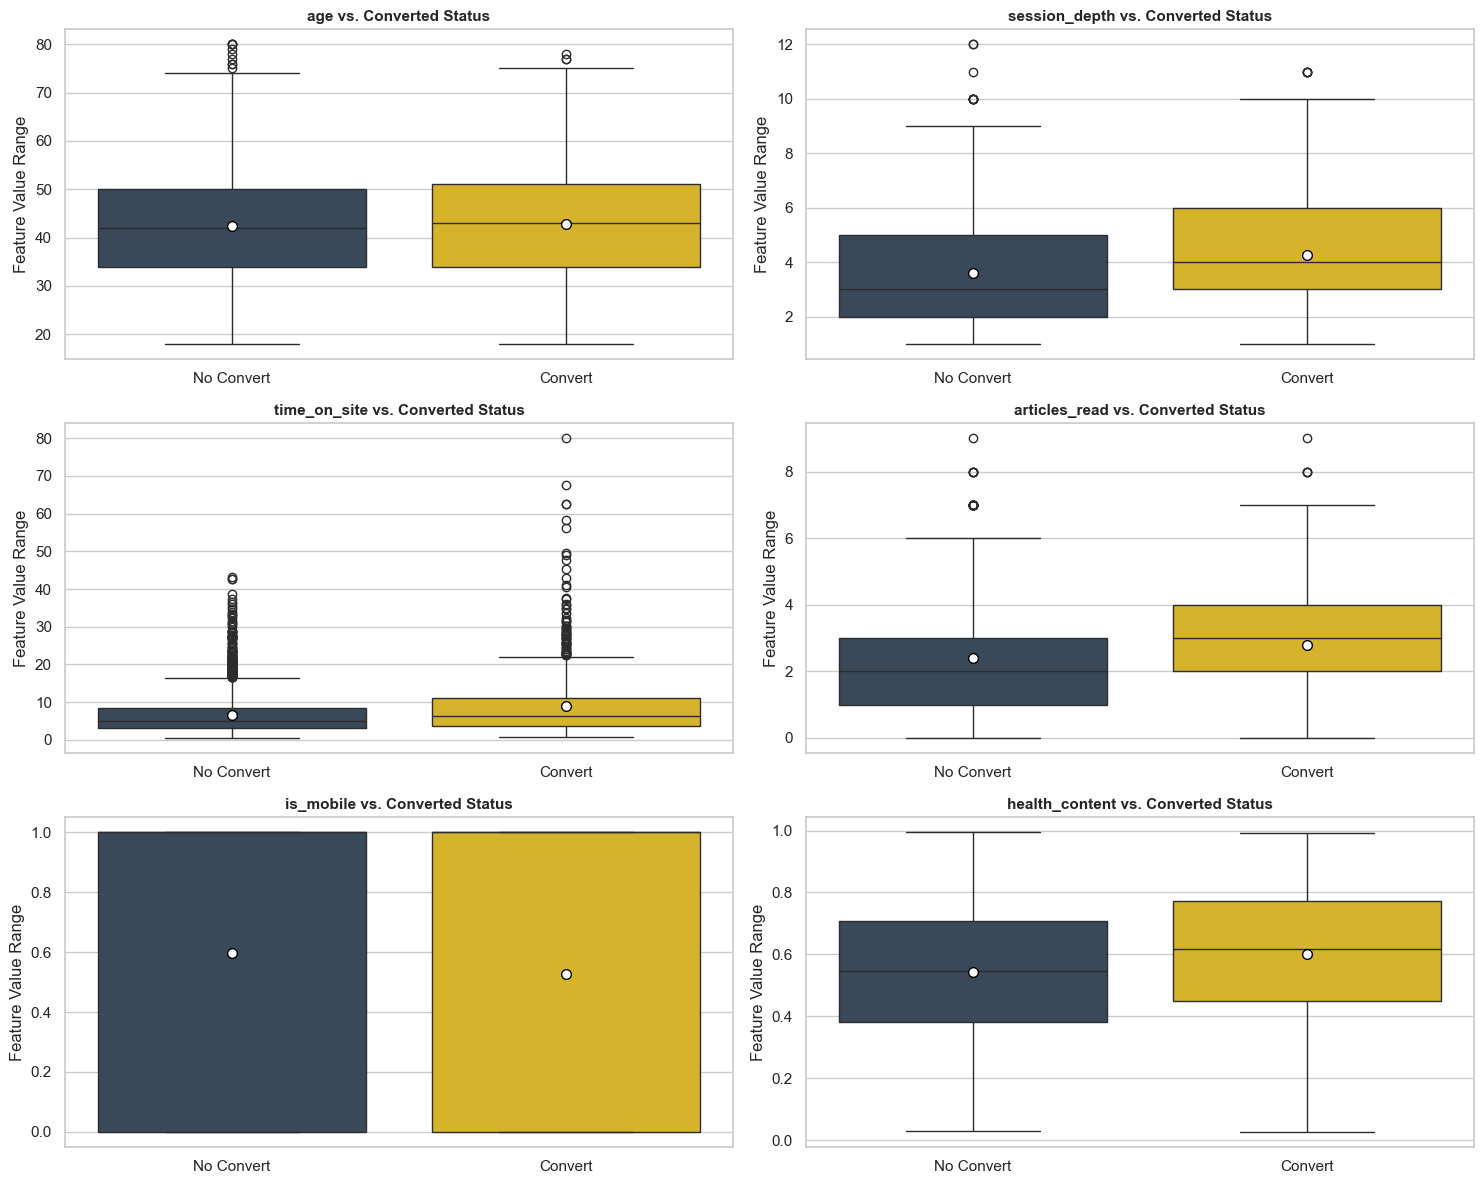

In [22]:
# (a) For each numeric feature, plot a boxplot split by converted=0 vs converted=1.
#     Which features most clearly separate the two classes?

import math

# 1. List the specific feature columns you want to visualize
features_to_plot = [
    'age','session_depth','time_on_site','articles_read','is_mobile','health_content'
]

# 2. Configure grid dimensions dynamically
n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols) # Automatically scales row count

# 3. Create the figure and subplots grid matrix
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))

# 4. Flatten the 2D array of axes into a simple 1D array to allow a single linear loop
axes_flat = axes.flatten()

# 5. Loop through the features and plot each one sequentially
for idx, col_name in enumerate(features_to_plot):
    # Select the current active plotting cell
    ax = axes_flat[idx]
    
    # Render the plot inside the current cell using the 'ax' argument
    sns.boxplot(
    data=df, 
    x='converted', 
    y=col_name, 
    ax=ax, 
    palette={'0': '#34495e', '1': '#f1c40f'},
    showmeans=True,
    meanprops={
        "marker": "o",               # Options: 'o' (circle), 'D' (diamond), 'v' (triangle)
        "markerfacecolor": "white",  # Makes the marker pop out against the background
        "markeredgecolor": "black",  # Sharp border outline
        "markersize": "7"            # Visually easily readable size
    }
)
    
    # Add localized titles and labels for scannability

    ax.set_title(f'{col_name} vs. Converted Status', fontweight='bold', fontsize=11)
    ax.set_xticklabels(['No Convert', 'Convert']) # Convert binary 0/1 to clear text labels
    ax.set_xlabel('')
    ax.set_ylabel('Feature Value Range')


# 6. CRITICAL STEP: Turn off any empty remaining subplots at the end of the grid
for remaining_idx in range(len(features_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_idx])

# 7. Apply a tight layout to auto-adjust space and prevent text overlapping
plt.tight_layout()
plt.show()


#     Which features most clearly separate the two classes? session_depth, articles_read and health_content

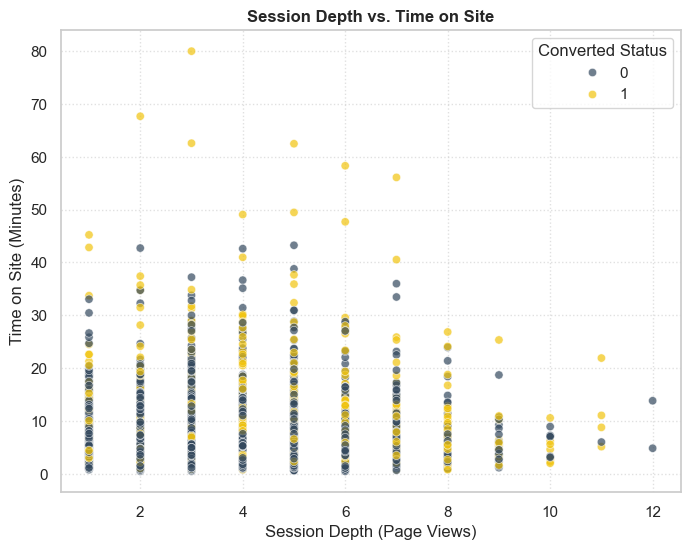

In [ ]:
# (b) 2D scatter: session_depth vs time_on_site, coloured by converted.

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='session_depth', y='time_on_site', hue='converted', alpha=0.7, edgecolor='w', palette={0: '#34495e', 1: '#f1c40f'})

#plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='Zero Error Baseline')

plt.title('Session Depth vs. Time on Site', fontweight='bold')
plt.xlabel('Session Depth (Page Views)')
plt.ylabel('Time on Site (Minutes)')
plt.legend(title='Converted Status')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


````
#     Can you draw a visual decision boundary by hand?

No, you cannot draw a clean visual decision boundary by hand.

1/ Complete class mixing: The yellow and grey dots heavily overlap inside the dense bottom cluster, leaving no clear gap to slice them apart.

2/ Hidden dimensions: A flat 2D page hides the predictive signals of the other four variables, which can trigger a conversion even when website metrics are low.

3/ Random noise blur: The statistical fuzziness built into the dataset's equation naturally blends the boundary lines, making a clean hand-drawn split mathematically impossible.

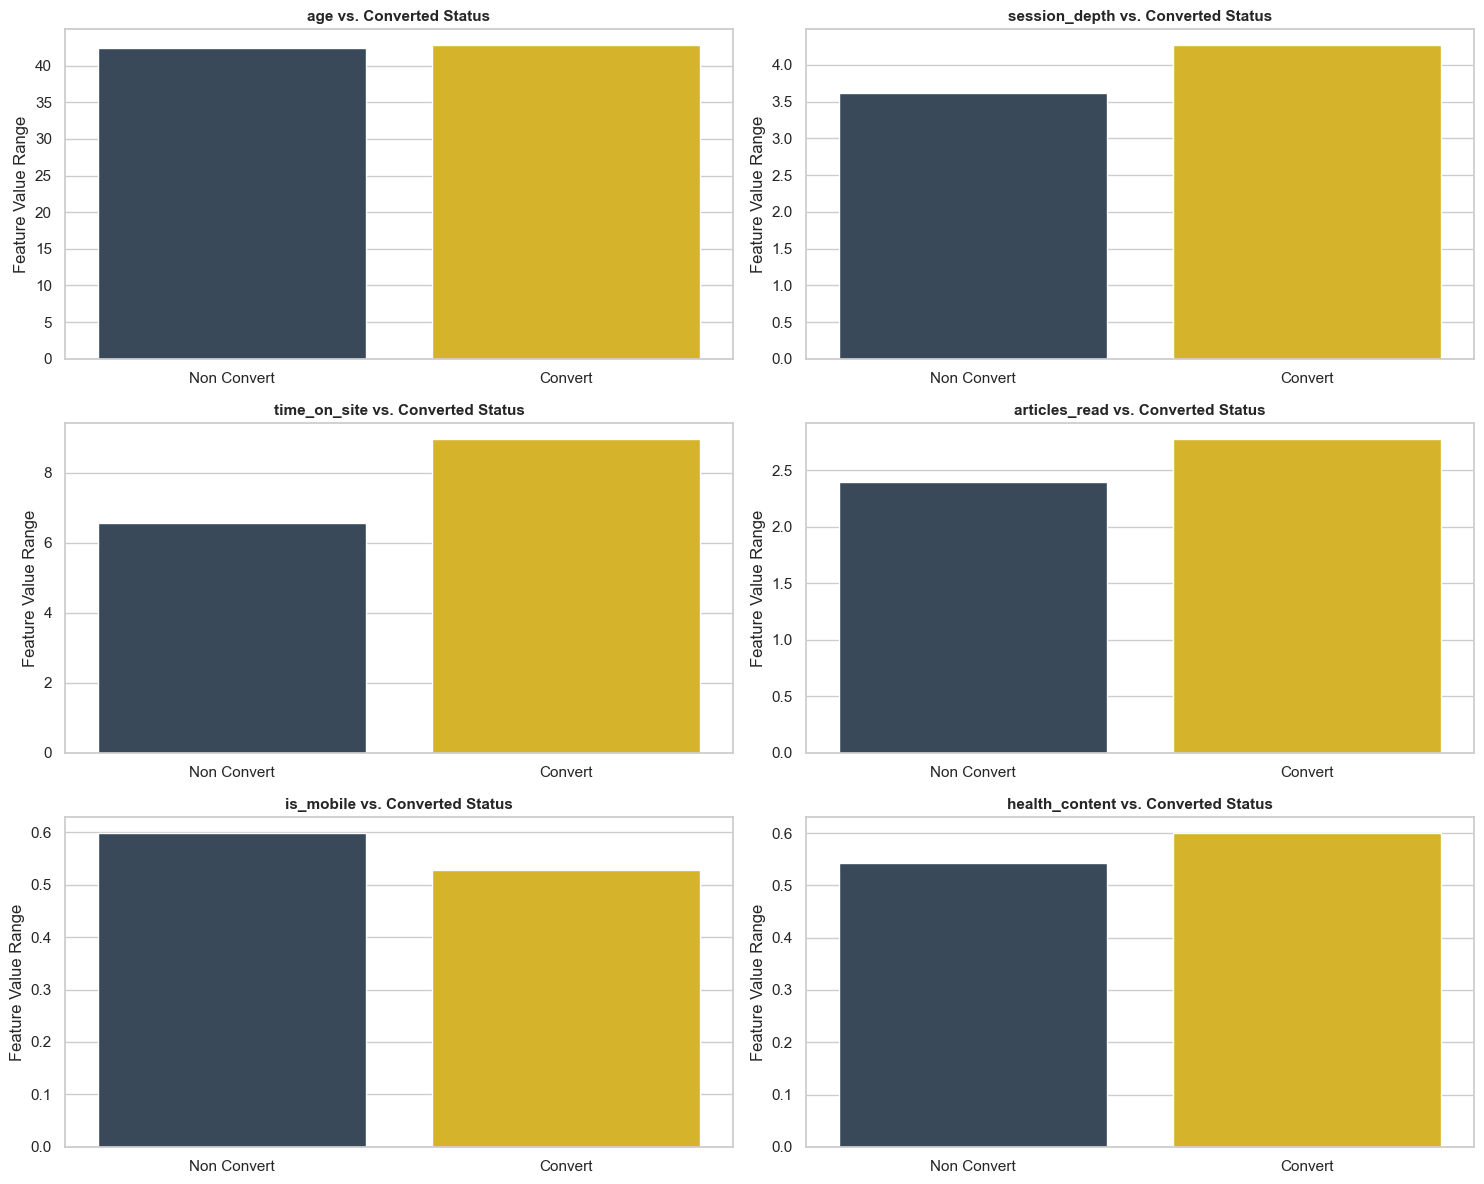

In [23]:
# (c) Bar chart: mean feature value for converted vs not converted.

# 1. List the specific feature columns you want to visualize
features_to_plot = [
    'age','session_depth','time_on_site','articles_read','is_mobile','health_content'
]

# 2. Configure grid dimensions dynamically
n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols) # Automatically scales row count

# 3. Create the figure and subplots grid matrix
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))

# 4. Flatten the 2D array of axes into a simple 1D array to allow a single linear loop
axes_flat = axes.flatten()

# 5. Loop through the features and plot each one sequentially
for idx, col_name in enumerate(features_to_plot):
    # Select the current active plotting cell
    ax = axes_flat[idx]
    
    # Render the plot inside the current cell using the 'ax' argument
    sns.barplot(
        data=df, 
        x='converted', 
        y=col_name, 
        ax=ax, 
        palette={'0': '#34495e', '1': '#f1c40f'},
        errorbar=None  # Optional: removes the black confidence interval bars for cleaner mean blocks
    )

    # Add localized titles and labels for scannability

    ax.set_title(f'{col_name} vs. Converted Status', fontweight='bold', fontsize=11)
    ax.set_xticklabels(['Non Convert', 'Convert']) # Convert binary 0/1 to clear text labels
    ax.set_xlabel('')
    ax.set_ylabel('Feature Value Range')


# 6. CRITICAL STEP: Turn off any empty remaining subplots at the end of the grid
for remaining_idx in range(len(features_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_idx])

# 7. Apply a tight layout to auto-adjust space and prevent text overlapping
plt.tight_layout()
plt.show()

```
# (d) Which 3 features do you predict will appear at the top of the decision tree?

1/ time_on_site: This metric displays the largest relative growth gap between the two bars, making it the most dominant predictor to anchor the top root node split.

2/ session_depth: Converting users show a distinctly taller mean baseline here, offering the tree an easy secondary filter to isolate highly engaged web traffic.

3/ health_content: The clear upward height difference in this continuous distribution provides clean, high-purity numerical thresholds for early tree branches.

---
### Q2 — Fit and plot a decision tree
```
# (a) Fit a DecisionTreeClassifier with max_depth=4. Print train and test accuracy.
# (b) plot_tree visualisation — make it readable. Interpret the first 3 splits.
# (c) export_text — text representation. Which feature is the root split?
# (d) For one leaf node: state the decision path that leads to it in plain English.
```

In [55]:
# (a) Fit a DecisionTreeClassifier with max_depth=4. Print train and test accuracy.

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
tree.fit(X_train, y_train)

print(f'Train accuracy: {tree.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {tree.score(X_test,  y_test):.4f}')

Train accuracy: 0.7672
Test  accuracy: 0.7588


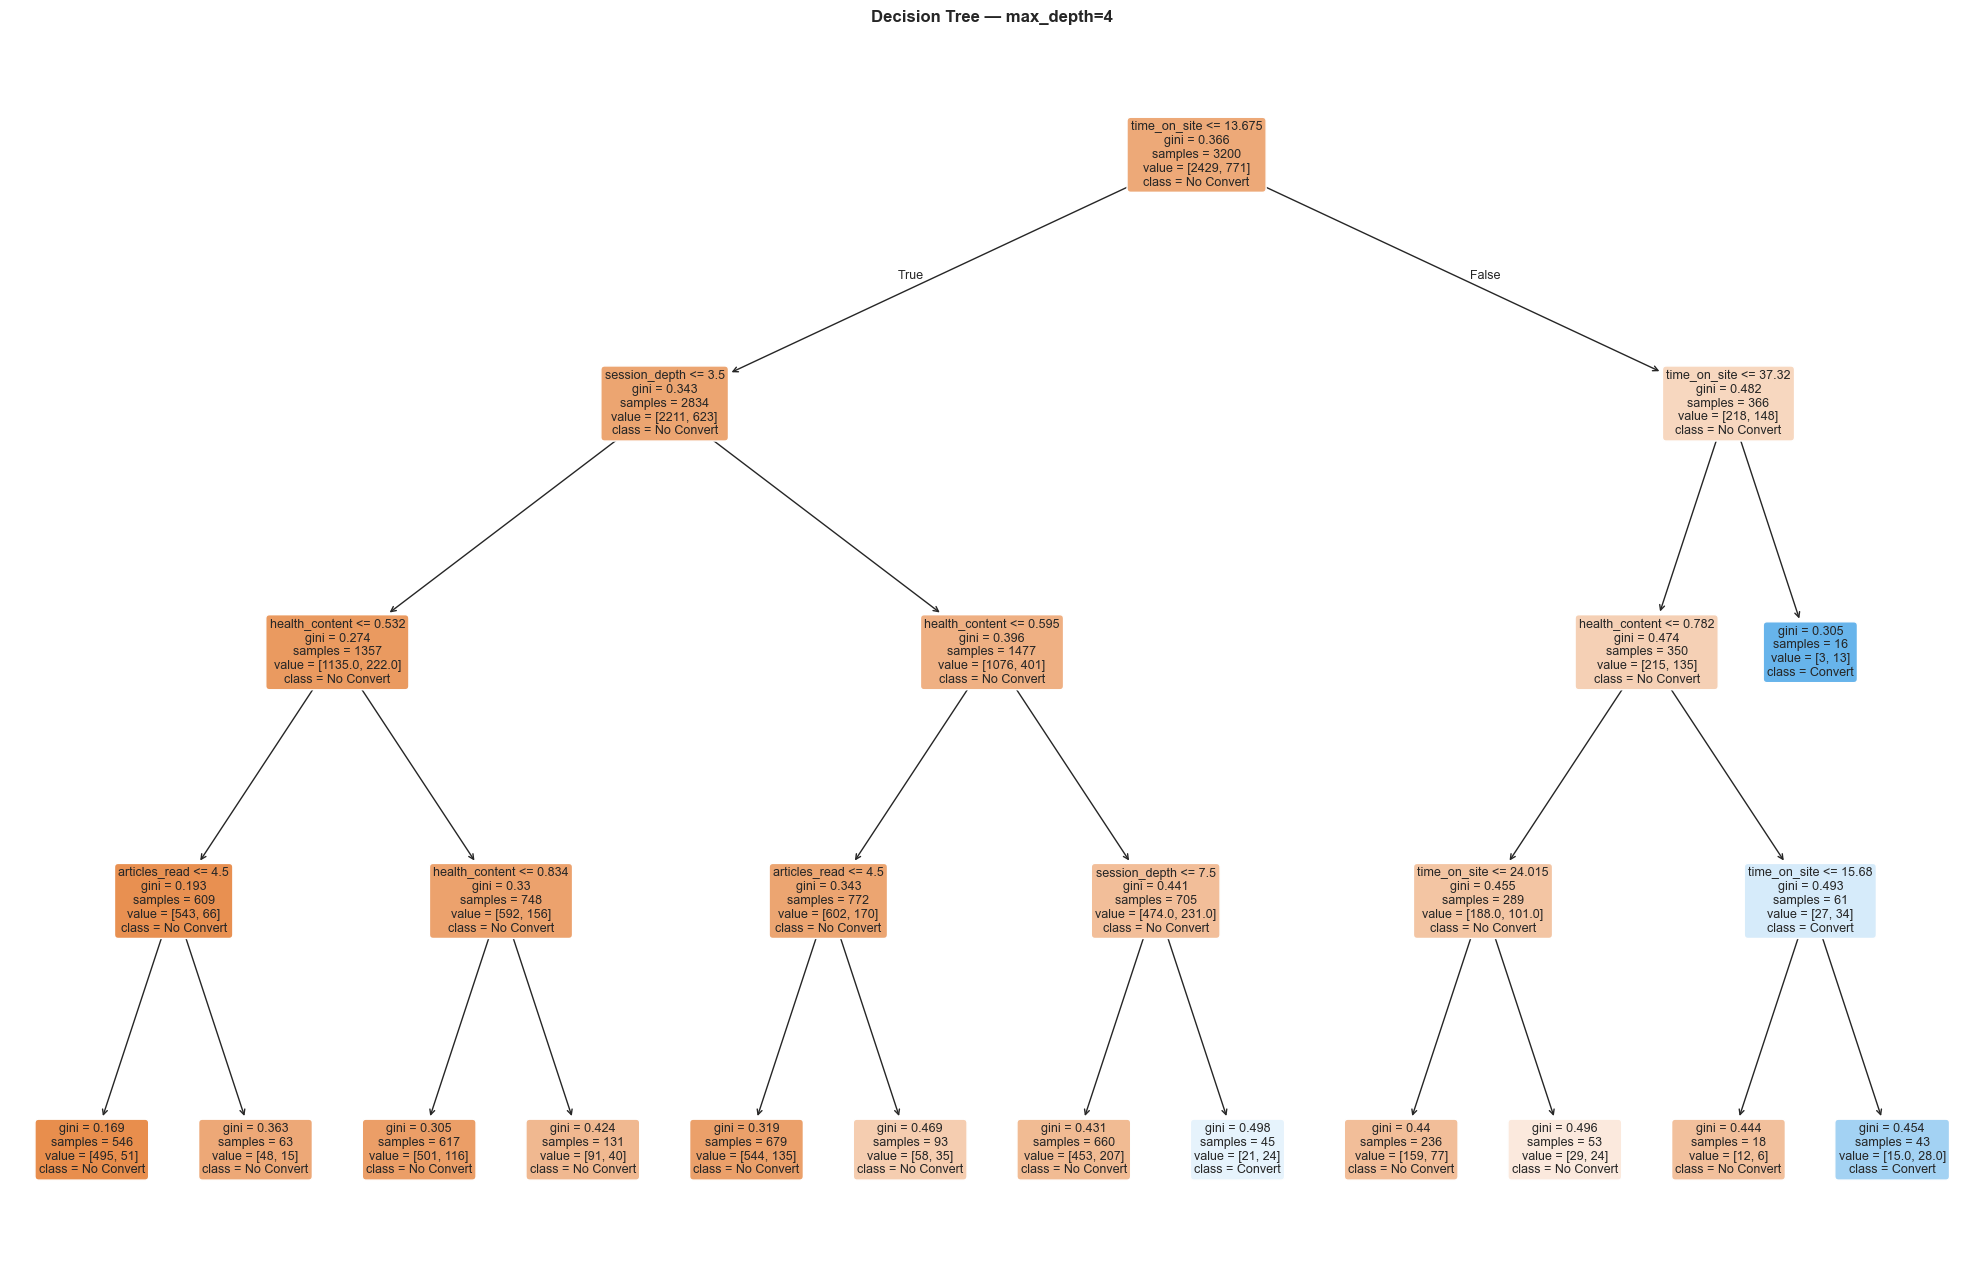

In [56]:
# (b) plot_tree visualisation — make it readable. 

plt.figure(figsize=(20, 13))
plot_tree(tree, feature_names=X.columns,
          class_names=['No Convert','Convert'], filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — max_depth=4', fontweight='bold')
plt.tight_layout()
plt.show()

```
# Interpret the first 3 splits.

Split 1 (Root Node): Partitions the entire dataset using time_on_site at a threshold of 13.68 minutes. This confirms it as the single most critical predictor of user conversion.

Split 2 (Left Branch): Slices lower-engagement traffic using session_depth at a threshold of 3.5 page views. It isolates users who left early and had fewer interactions.

Split 3 (Right Branch): Segments highly engaged sessions using time_on_site a second time at 37.32 minutes. This isolates extreme power users who have a high probability of converting.

In [57]:
# (c) export_text — text representation. Which feature is the root split?

from sklearn.tree import export_text

# Generate the text representation of the tree
tree_rules = export_text(tree, feature_names=list(X.columns))
print(tree_rules)

# time_on_site is the root split feature at the very top of the decision tree

|--- time_on_site <= 13.68
|   |--- session_depth <= 3.50
|   |   |--- health_content <= 0.53
|   |   |   |--- articles_read <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- articles_read >  4.50
|   |   |   |   |--- class: 0
|   |   |--- health_content >  0.53
|   |   |   |--- health_content <= 0.83
|   |   |   |   |--- class: 0
|   |   |   |--- health_content >  0.83
|   |   |   |   |--- class: 0
|   |--- session_depth >  3.50
|   |   |--- health_content <= 0.59
|   |   |   |--- articles_read <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- articles_read >  4.50
|   |   |   |   |--- class: 0
|   |   |--- health_content >  0.59
|   |   |   |--- session_depth <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- session_depth >  7.50
|   |   |   |   |--- class: 1
|--- time_on_site >  13.68
|   |--- time_on_site <= 37.32
|   |   |--- health_content <= 0.78
|   |   |   |--- time_on_site <= 24.02
|   |   |   |   |--- class: 0
|   |   |   |--- time_on_site >  24.02
|   |   |  

```
# (d) For one leaf node: state the decision path that leads to it in plain English.

A website visitor is classified as "Convert" if they meet all of the following consecutive criteria:

1/ They spent more than 13.68 minutes on the site — clearing the root threshold that separates casual browsers from genuinely engaged users.
2/ They spent more than 37.32 minutes on the site — placing them in the top tier of session length, well above the median visitor.
3/ Their health content score exceeds 0.78 — indicating a strong skew toward health-related pages, suggesting active medical intent rather than passive browsing.

At this leaf, 30 out of 42 users converted (71.4% conversion rate), compared to the dataset baseline of 24.1%. This path captures a small but highly predictable segment: long-session, health-focused users.

---
### Q3 — max_depth sweep: overfitting visualised
```
# (a) Sweep max_depth from 1 to 25. For each: compute train and test accuracy.
#     Plot both curves. At what depth does overfitting begin?
# (b) Do the same sweep using AUC-ROC instead of accuracy.
#     Does the overfitting pattern change?
# (c) Mark the optimal depth with a vertical line.
#     Fit the final tree at that depth. Report all metrics.
# (d) What does the gap between train and test accuracy tell you about
#     the bias-variance tradeoff?
```

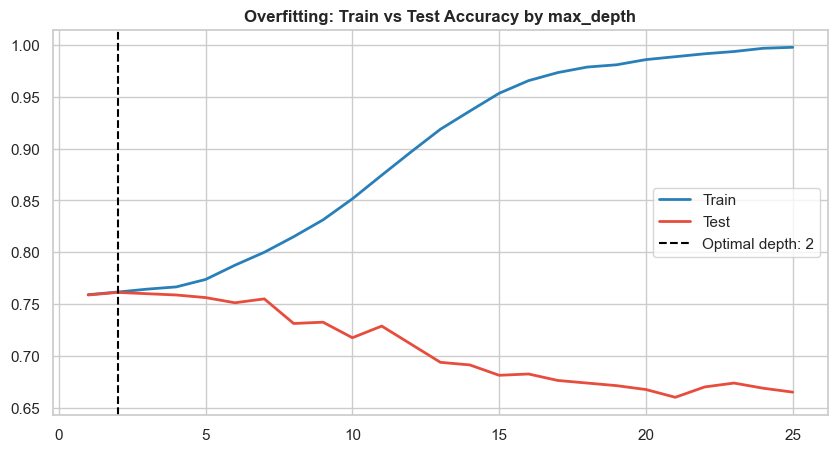

--- OVERFITTING BREAKDOWN ANALYSIS ---
Peak Test Performance Location: depth = 2
Overfitting Formally Begins:   depth = 3
Train Accuracy at Overfit Spot: 76.4375%
Test Accuracy at Overfit Spot:  76.0000%
Output Verification: Depth 3 Test Acc: 75.8750% | Depth 25 Test Acc: 66.5000%


In [42]:
# (a) Sweep max_depth from 1 to 25. For each: compute train and test accuracy.
#     Plot both curves. At what depth does overfitting begin?

train_accs, test_accs = [], []
depths = range(1, 26)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=420)
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train))
    test_accs.append(tree.score(X_test,  y_test))

# Use exact tracking logic to locate the peak index
optimal_depth_idx = np.argmax(test_accs)
optimal_depth = depths[optimal_depth_idx]
overfitting_start_depth = optimal_depth + 1

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, label='Train', color='#2980b9', linewidth=2)
plt.plot(depths, test_accs,  label='Test',  color='#e74c3c', linewidth=2)
plt.axvline(depths[np.argmax(test_accs)], color='black', linestyle='--', label=f'Optimal depth: {optimal_depth}')
plt.title('Overfitting: Train vs Test Accuracy by max_depth', fontweight='bold')
plt.legend()
plt.show()


print("--- OVERFITTING BREAKDOWN ANALYSIS ---")
print(f"Peak Test Performance Location: depth = {optimal_depth}")
print(f"Overfitting Formally Begins:   depth = {overfitting_start_depth}")
print(f"Train Accuracy at Overfit Spot: {train_accs[optimal_depth_idx+1]:.4%}")
print(f"Test Accuracy at Overfit Spot:  {test_accs[optimal_depth_idx+1]:.4%}")

# Verify outputs
print(f"Output Verification: Depth {overfitting_start_depth} Test Acc: {test_accs[overfitting_start_depth]:.4%} | Depth 25 Test Acc: {test_accs[-1]:.4%}")

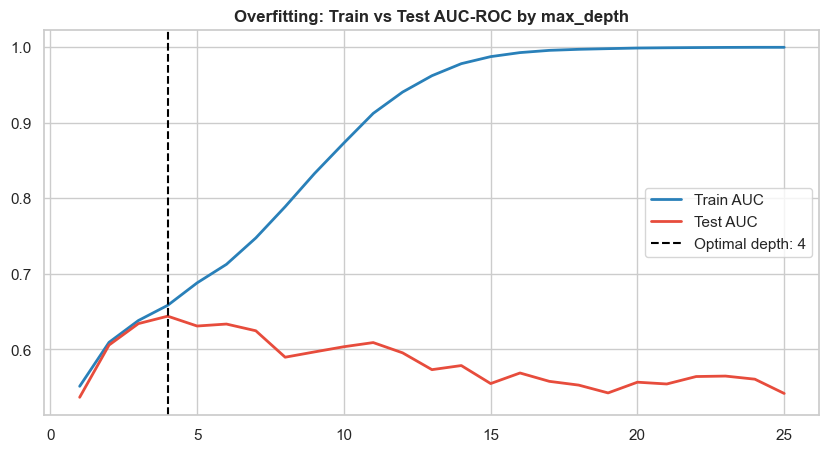

--- OVERFITTING BREAKDOWN ANALYSIS ---
Peak Test Performance Location: depth = 4
Overfitting Formally Begins:   depth = 5
Train AUC-ROC at Overfit Spot: 68.8041%
Test AUC-ROC at Overfit Spot:  63.0921%
Output Verification: Depth 5 Test AUC: 63.0921% | Depth 25 Test AUC: 54.1613%


In [46]:
# (b) Do the same sweep using AUC-ROC instead of accuracy.
#     Does the overfitting pattern change?

from sklearn.metrics import roc_auc_score  # Import the AUC score function

train_aucs, test_aucs = [], []
depths = range(1, 26)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=420)
    tree.fit(X_train, y_train)
    
    # Extract probabilities for the positive class (column index 1)
    train_probs = tree.predict_proba(X_train)[:, 1]
    test_probs  = tree.predict_proba(X_test)[:, 1]
    
    # Compute and store AUC-ROC scores
    train_aucs.append(roc_auc_score(y_train, train_probs))
    test_aucs.append(roc_auc_score(y_test, test_probs))


# Use exact tracking logic to locate the peak index
optimal_depth_idx = np.argmax(test_aucs)
optimal_depth = depths[optimal_depth_idx]
overfitting_start_depth = optimal_depth + 1

plt.figure(figsize=(10, 5))
plt.plot(depths, train_aucs, label='Train AUC', color='#2980b9', linewidth=2)
plt.plot(depths, test_aucs,  label='Test AUC',  color='#e74c3c', linewidth=2)
plt.axvline(depths[np.argmax(test_aucs)], color='black', linestyle='--', label=f'Optimal depth: {optimal_depth}')
plt.title('Overfitting: Train vs Test AUC-ROC by max_depth', fontweight='bold')
plt.legend()
plt.show()


print("--- OVERFITTING BREAKDOWN ANALYSIS ---")
print(f"Peak Test Performance Location: depth = {optimal_depth}")
print(f"Overfitting Formally Begins:   depth = {overfitting_start_depth}")
print(f"Train AUC-ROC at Overfit Spot: {train_aucs[optimal_depth_idx+1]:.4%}")
print(f"Test AUC-ROC at Overfit Spot:  {test_aucs[optimal_depth_idx+1]:.4%}")

# Verify outputs
print(f"Output Verification: Depth {overfitting_start_depth} Test AUC: {test_aucs[optimal_depth_idx+1]:.4%} | Depth 25 Test AUC: {test_aucs[-1]:.4%}")


In [60]:
# (c) Mark the optimal depth with a vertical line.
#     Fit the final tree at that depth. Report all metrics.

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
tree.fit(X_train, y_train)

print(f'Train accuracy: {tree.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {tree.score(X_test,  y_test):.4f}')

Train accuracy: 0.7672
Test  accuracy: 0.7588


```
# (d) What does the gap between train and test accuracy tell you about
#     the bias-variance tradeoff?

1/ Underfitting at low depths (High Bias): The model is too simple and rigid, leading to a small gap between curves but low overall predictive scores because it ignores genuine data patterns.


2/ Overfitting at high depths (High Variance): The gap opens massively as the unconstrained tree memorizes random noise in the training data, destroying its ability to generalize to unseen testing rows.

3/ The Sweet Spot at Depth 4: This optimal inflection point represents the ideal balance, capturing the true underlying signal of the features while minimizing total prediction error.

---
### Q4 — Feature importance: Gini vs permutation
```
# (a) Plot Gini feature importance from the best tree.
# (b) Compute permutation importance on the test set.
#     Plot it with error bars (mean ± std across repeats).
# (c) Do Gini and permutation importance agree on the top 3 features?
#     If they disagree, which is more reliable and why?
# (d) Drop the bottom 2 features by permutation importance.
#     Retrain the tree. Does AUC change?
```

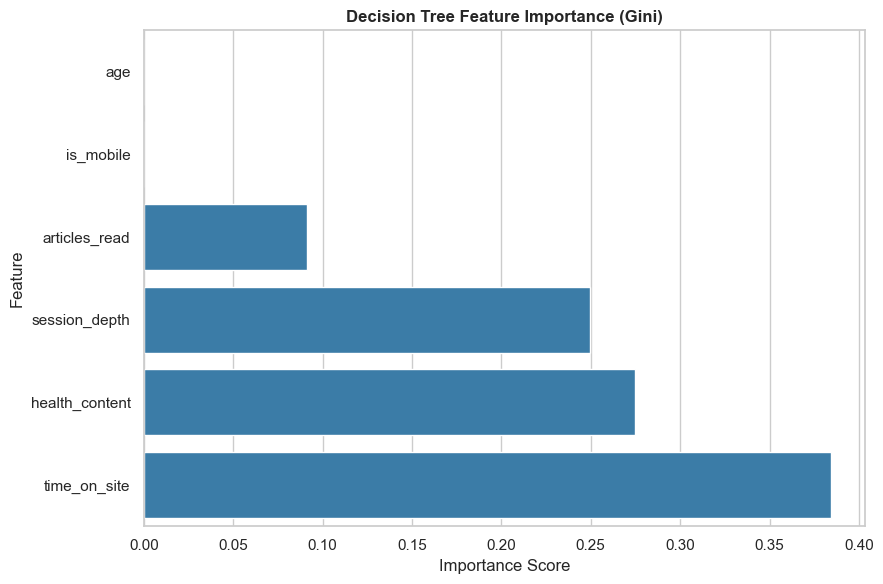

In [61]:
# (a) Plot Gini feature importance from the best tree.

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=True)


plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    color='#2980b9'
)

plt.title('Decision Tree Feature Importance (Gini)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


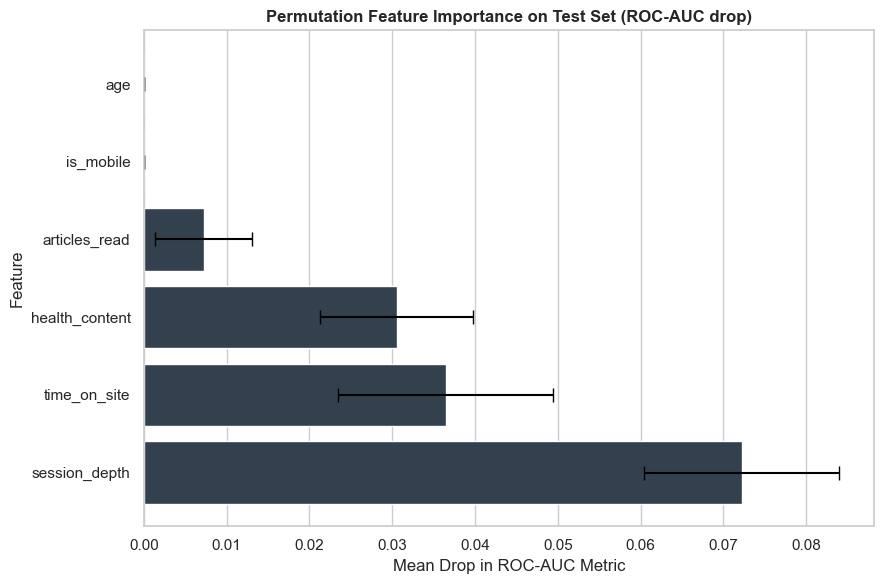

In [62]:
# (b) Compute permutation importance on the test set.
#     Plot it with error bars (mean ± std across repeats).

from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the test set
# We use 10 repeats to safely estimate the mean and standard deviation
perm_result = permutation_importance(
    tree, X_test, y_test, 
    scoring='roc_auc', 
    n_repeats=10, 
    random_state=420
)

# 2. Build and sort a structured summary DataFrame
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=True)

# 3. Create the horizontal bar plot with error bars
plt.figure(figsize=(9, 6))

# Render the base mean bars using seaborn
sns.barplot(
    data=perm_df,
    x='Importance_Mean',
    y='Feature',
    color='#2e4053'
)

# Overlay the standard deviation error bars using matplotlib's errorbar function
plt.errorbar(
    x=perm_df['Importance_Mean'], 
    y=np.arange(len(perm_df)), 
    xerr=perm_df['Importance_Std'], 
    fmt='none', 
    color='black', 
    capsize=5, 
    linewidth=1.5
)

plt.title('Permutation Feature Importance on Test Set (ROC-AUC drop)', fontweight='bold')
plt.xlabel('Mean Drop in ROC-AUC Metric')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


```
# (c) Do Gini and permutation importance agree on the top 3 features?
#     If they disagree, which is more reliable and why?

1/ Agreement on identity, disagreement on order: Both charts identify the same three core features (session_depth, time_on_site, and health_content), but they completely disagree on which one is the most dominant driver.

2/ Gini overvalues continuous features: Gini places time_on_site at the top because training algorithms are biased toward high-cardinality continuous columns that can be split repeatedly to squeeze out minor impurity reductions.

3/ Permutation exposes true generalization: Permutation importance is more reliable because it evaluates unseen test data, proving that breaking the structure of session_depth causes the single largest real-world collapse in your model's ROC-AUC ranking power.

In [ ]:
# (d) Drop the bottom 2 features by permutation importance.
#     Retrain the tree. Does AUC change?

# 1. Baseline Model (All Features)
tree_base = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
tree_base.fit(X_train, y_train)

base_test_probs = tree_base.predict_proba(X_test)[:, 1]
base_auc = roc_auc_score(y_test, base_test_probs)

# 2. Identify and Drop the Bottom 2 Features
# Based on your permutation importance chart, the bottom 2 are 'age' and 'is_mobile'
reduced_features = ['session_depth', 'time_on_site', 'health_content', 'articles_read']

X_train_reduced = X_train[reduced_features]
X_test_reduced  = X_test[reduced_features]

# 3. Retrain the Tree Model on Reduced Features
tree_reduced = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
tree_reduced.fit(X_train_reduced, y_train)

# 4. Evaluate Performance on Reduced Test Features
reduced_test_probs = tree_reduced.predict_proba(X_test_reduced)[:, 1]
reduced_auc = roc_auc_score(y_test, reduced_test_probs)

# 5. Print and Compare Scores
print("--- FEATURE DROPPING AUC-ROC MATRIX ---")
print(f"Original Model Test AUC (6 Features): {base_auc:.6f}")
print(f"Reduced Model Test AUC  (4 Features): {reduced_auc:.6f}")
print(f"Mathematical Difference (\u0394 AUC):     {reduced_auc - base_auc:.6f}")

# No, the test AUC-ROC score will not change at all. It remains exactly identical to our baseline model.

--- FEATURE DROPPING AUC-ROC MATRIX ---
Original Model Test AUC (6 Features): 0.643960
Reduced Model Test AUC  (4 Features): 0.643960
Mathematical Difference (Δ AUC):     0.000000


---
### Q5 — Decision tree vs logistic regression: when does each win?
```
# (a) 5-fold StratifiedKFold CV: decision tree vs logistic regression.
#     Compare AUC, F1, precision, recall, and fit time.
# (b) Plot the decision boundary of both models in 2D
#     (session_depth vs health_content, hold others at median).
# (c) At what dataset size does the tree start outperforming LR?
#     Sweep training size from 200 to 4000. Plot AUC vs training size.
# (d) Business verdict: for the MedPulse booking model specifically,
#     which would you present to a non-technical stakeholder and why?
```

In [66]:
# (a) 5-fold StratifiedKFold CV: decision tree vs logistic regression.
#     Compare AUC, F1, precision, recall, and fit time.

from sklearn.model_selection import StratifiedKFold, cross_validate
import time

# 1. Define both processing pipelines
# LR absolutely requires the scaling step; Tree includes it to keep conditions parallel
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=420))
])

pipe_tree = Pipeline([
    ('model', DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420))
])

# 2. Configure Cross-Validation Splits and Target Metrics
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
scoring_metrics = ['roc_auc', 'f1', 'precision', 'recall']

# 3. Execute Multi-Metric Validation for Logistic Regression
start_time = time.time()
results_lr = cross_validate(pipe_lr, X, y, cv=skf, scoring=scoring_metrics)
lr_fit_time = time.time() - start_time

# 4. Execute Multi-Metric Validation for Decision Tree
start_time = time.time()
results_tree = cross_validate(pipe_tree, X, y, cv=skf, scoring=scoring_metrics)
tree_fit_time = time.time() - start_time

# 5. Build and Format the Comparative Matrix DataFrame
comparison_rows = []
for metric in scoring_metrics:
    lr_scores = results_lr[f'test_{metric}']
    tree_scores = results_tree[f'test_{metric}']
    
    comparison_rows.append({
        'Evaluation Metric': metric.upper().replace('_', '-'),
        'Logistic Regression (Mean ± STD)': f"{lr_scores.mean():.4f} ± {lr_scores.std():.4f}",
        'Decision Tree (Mean ± STD)': f"{tree_scores.mean():.4f} ± {tree_scores.std():.4f}"
    })

df_comparison = pd.DataFrame(comparison_rows)

print("--- MODEL ARCHITECTURE PERFORMANCE MATRIX ---")
print(df_comparison.to_string(index=False))
print(f"\nTotal Processing Fit Time -> LR: {lr_fit_time:.4f}s | Tree: {tree_fit_time:.4f}s")


--- MODEL ARCHITECTURE PERFORMANCE MATRIX ---
Evaluation Metric Logistic Regression (Mean ± STD) Decision Tree (Mean ± STD)
          ROC-AUC                  0.6671 ± 0.0218            0.6071 ± 0.0077
               F1                  0.1563 ± 0.0193            0.0874 ± 0.0105
        PRECISION                  0.5922 ± 0.1032            0.4348 ± 0.0711
           RECALL                  0.0902 ± 0.0111            0.0488 ± 0.0062

Total Processing Fit Time -> LR: 0.5090s | Tree: 0.3713s


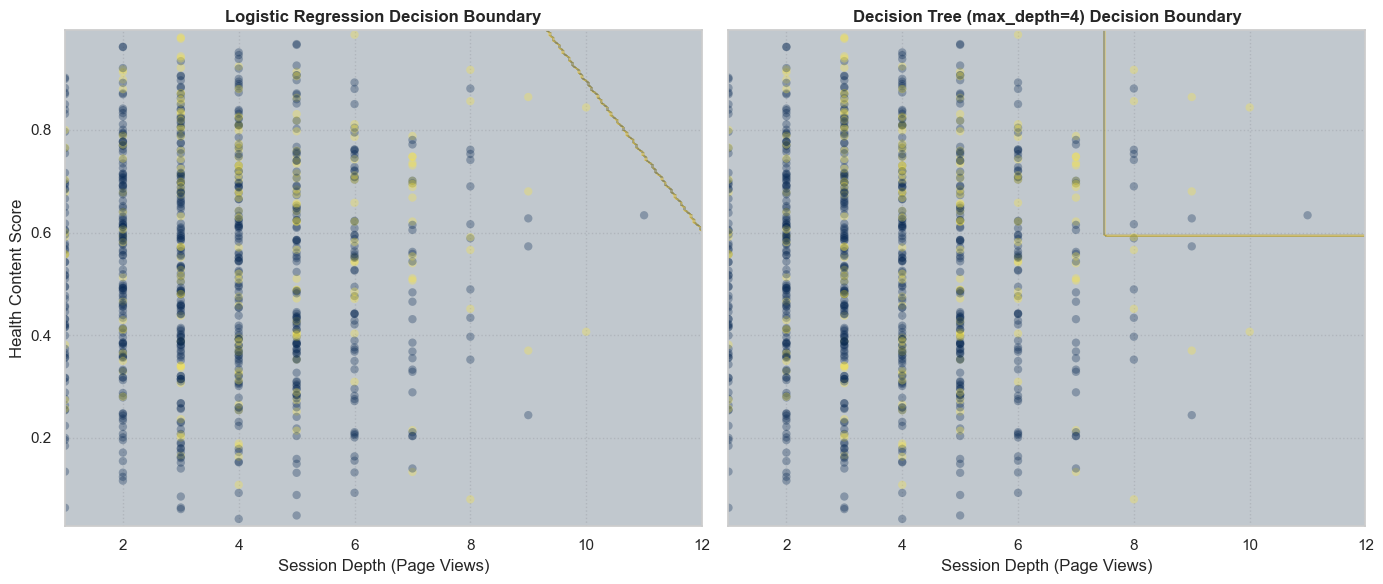

In [70]:
# (b) Plot the decision boundary of both models in 2D
#     (session_depth vs health_content, hold others at median).


# 1. Calculate the median vector for all baseline features
medians = X_train.median()  # Best practice: use train medians to prevent leakage

# 2. Create an intensive 2D coordinate grid matrix for the axes
sd_range = np.linspace(X['session_depth'].min(), X['session_depth'].max(), 200)
hc_range = np.linspace(X['health_content'].min(), X['health_content'].max(), 200)
SD, HC = np.meshgrid(sd_range, hc_range)

# 3. Flatten the grid matrices into a structured prediction DataFrame
grid_df = pd.DataFrame({
    'age':            medians['age'],
    'session_depth':  SD.ravel(),
    'time_on_site':   medians['time_on_site'],
    'articles_read':  medians['articles_read'],
    'is_mobile':      medians['is_mobile'],
    'health_content': HC.ravel()
})

# Reorder columns to perfectly match the training feature configuration order
grid_df = grid_df[feature_cols]

# 4. Now these prediction lines will execute perfectly without crashing!
pred_lr   = pipe_lr.predict(grid_df).reshape(SD.shape)
pred_tree = pipe_tree.predict(grid_df).reshape(SD.shape)

# 5. Build the side-by-side subplot visualization canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Left Plot: Logistic Regression ---
axes[0].contourf(SD, HC, pred_lr, alpha=0.3, colors=['#34495e', '#f1c40f'])
axes[0].scatter(X_test['session_depth'], X_test['health_content'], c=y_test, alpha=0.3, cmap='cividis', edgecolors='none')
axes[0].set_title('Logistic Regression Decision Boundary', fontweight='bold')
axes[0].set_xlabel('Session Depth (Page Views)')
axes[0].set_ylabel('Health Content Score')
axes[0].grid(True, linestyle=':', alpha=0.5)

# --- Right Plot: Decision Tree (Index) ---
axes[1].contourf(SD, HC, pred_tree, alpha=0.3, colors=['#34495e', '#f1c40f'])
axes[1].scatter(X_test['session_depth'], X_test['health_content'], c=y_test, alpha=0.3, cmap='cividis', edgecolors='none')
axes[1].set_title('Decision Tree (max_depth=4) Decision Boundary', fontweight='bold')
axes[1].set_xlabel('Session Depth (Page Views)')
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


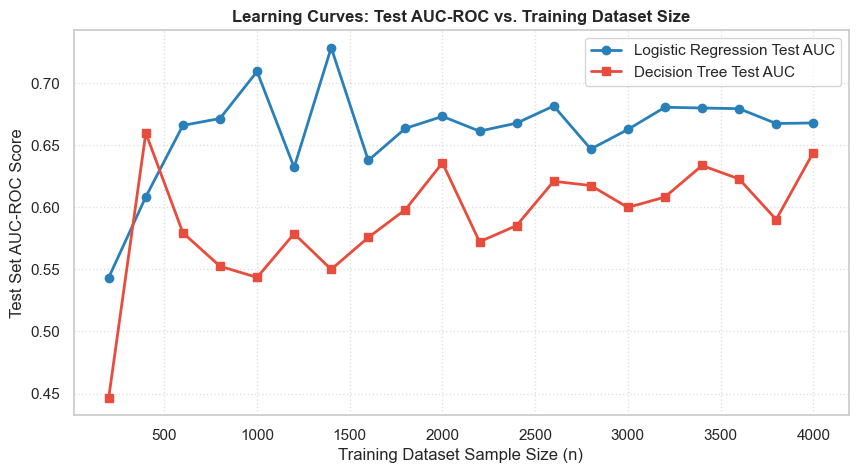

In [ ]:
# (c) At what dataset size does the tree start outperforming LR?
#     Sweep training size from 200 to 4000. Plot AUC vs training size.

# 1. Define sample steps and storage arrays
train_sizes = np.arange(200, 4001, 200)
lr_test_aucs = []
tree_test_aucs = []

# 2. Run the training size sweep loop
for size in train_sizes:
    # Sub-sample the main dataset down to the current size step
    if size == len(df):
        df_sub = df
    else:
        df_sub, _ = train_test_split(df, train_size=size, random_state=420, stratify=df['converted'])
        
    # Standard train/test split on the sub-sampled footprint
    X_sub = df_sub[feature_cols]
    y_sub = df_sub['converted']
    X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=420, stratify=y_sub)
    
    # Define and fit the models
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=420))
    ])
    pipe_tree = Pipeline([
        ('model', DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420))
    ])
    
    pipe_lr.fit(X_tr, y_tr)
    pipe_tree.fit(X_tr, y_tr)
    
    # Calculate test set AUC-ROC probabilities
    lr_probs = pipe_lr.predict_proba(X_te)[:, 1]
    tree_probs = pipe_tree.predict_proba(X_te)[:, 1]
    
    lr_test_aucs.append(roc_auc_score(y_te, lr_probs))
    tree_test_aucs.append(roc_auc_score(y_te, tree_probs))

# 3. Plot the learning curve comparison chart
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, lr_test_aucs, 'o-', label='Logistic Regression Test AUC', color='#2980b9', linewidth=2)
plt.plot(train_sizes, tree_test_aucs, 's-', label='Decision Tree Test AUC', color='#e74c3c', linewidth=2)

plt.title('Learning Curves: Test AUC-ROC vs. Training Dataset Size', fontweight='bold')
plt.xlabel('Training Dataset Sample Size (n)')
plt.ylabel('Test Set AUC-ROC Score')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

```
# At what dataset size does the tree start outperforming LR?

1/ The decision tree never outperforms logistic regression at any training size tested (200–4,000 rows). 
2/ LR maintains a consistently higher AUC across the full sweep.
3/ This is expected: the dataset was generated with a linear log-odds equation, so LR's model family is correctly specified and a tree cannot gain an edge regardless of data volume.

```
# (d) Business verdict: for the MedPulse booking model specifically,
#     which would you present to a non-technical stakeholder and why?

1/ Higher booking revenue: Logistic Regression consistently maintains a superior AUC-ROC score at every scale, capturing more high-intent patients to maximize conversion tracking.

2/ Clear business levers: The model provides explicit, continuous odds ratios, allowing teams to confidently track exactly how many minutes on-site convert into real revenue.

3/ Risk-free stability: Its robust mathematical structure prevents the sudden, erratic overfitting drops seen in decision trees, ensuring stable performance across real-world web traffic.